$\textbf{Project 3}$

Yasamin Modabber

Student ID : 97101059

In [1]:
using DataFrames , CSV
using Statistics
using CategoricalArrays
using GLM
using Plots
using Lathe.preprocess: TrainTestSplit
using MLBase
theme(:juno)

Problem 1:

In [2]:
df1=CSV.read("C:\\Users\\LENOVO\\Downloads\\Salary_Data.CSV",DataFrame)

,YearsExperience,Salary
,Float64,Float64
1,1.1,39343.0
2,1.3,46205.0
3,1.5,37731.0
4,2.0,43525.0
5,2.2,39891.0
6,2.9,56642.0
7,3.0,60150.0
8,3.2,54445.0
9,3.2,64445.0


In [3]:
average=round(mean(skipmissing(df1.YearsExperience)),digits=1)
replace!(df1.YearsExperience,missing => average);

In [74]:
ols = lm(@formula(Salary ~ YearsExperience) , df1)

StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}}}}, Matrix{Float64}}

Salary ~ 1 + YearsExperience

Coefficients:
────────────────────────────────────────────────────────────────────────────
                    Coef.  Std. Error      t  Pr(>|t|)  Lower 95%  Upper 95%
────────────────────────────────────────────────────────────────────────────
(Intercept)      25792.2     2273.05   11.35    <1e-11   21136.1     30448.3
YearsExperience   9449.96     378.755  24.95    <1e-19    8674.12    10225.8
────────────────────────────────────────────────────────────────────────────

The R-squared value is :0.9569566641435086


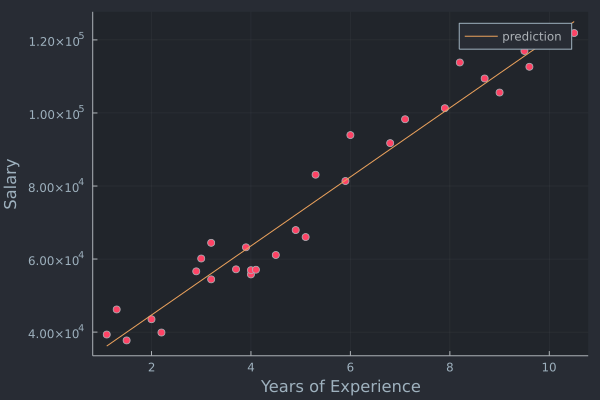

In [78]:
println("The R-squared value is :" , r2(ols))
p=Plots.plot(df1.YearsExperience ,df1.Salary,seriestype=:scatter,label=false)
xlabel!("Years of Experience")
ylabel!("Salary")
Plots.plot!(p, df1.YearsExperience , [coef(ols)[1]+coef(ols)[2]*i for i ∈ df1.YearsExperience],label="prediction")

$\textbf{Results:}$

In simple or multiple linear regression, the size of the coefficient for each independent variable gives us the size of the effect that variable is having on your dependent variable, and the sign on the coefficients (positive or negative) gives you the direction of the effect. In regression with multiple independent variables, the coefficient tells you how much the dependent variable is expected to increase when that independent variable increases by one, holding all the other independent variables constant.

From observing the intercept we understand that the minimum pay for the job is around 25,792$ and with each year of experince each individual has, they will have around 9450$ added to their Salary.

With a P value of 0.05 there is only a 5% chance that results we are seeing would have come up in a random distribution, so we can say with a 95% probability of being correct that the variable is having some effect. here the P value is much smaller than 0.05 so the data have good correlation.

The High R-squared of the regression tells us that the fraction of the variation in Salary is nicely accounted for by years of experience.

...........................................................................................................................................................................................................................................................................................................................................................................................

Problem 2:

In [79]:
df2=CSV.read("C:\\Users\\LENOVO\\Downloads\\50_Startups.CSV",DataFrame)
DataFrames.rename!(df2 , Dict(:"R&D Spend" => "RD_Spend"))
DataFrames.rename!(df2 , Dict(:"Marketing Spend" => "Marketing_Spend"))

,RD_Spend,Administration,Marketing_Spend,State,Profit
,Float64,Float64,Float64,String15,Float64
1,1.65349e5,1.36898e5,4.71784e5,New York,1.92262e5
2,1.62598e5,1.51378e5,4.43899e5,California,1.91792e5
3,1.53442e5,1.01146e5,4.07935e5,Florida,1.9105e5
4,1.44372e5,1.18672e5,3.832e5,New York,182902.0
5,1.42107e5,91391.8,3.66168e5,Florida,1.66188e5
6,1.31877e5,99814.7,3.62861e5,New York,1.56991e5
7,1.34615e5,1.47199e5,1.27717e5,California,1.56123e5
8,1.30298e5,1.4553e5,3.23877e5,Florida,1.55753e5
9,1.20543e5,148719.0,3.11613e5,New York,1.52212e5


In [80]:
#R&D Spend
fm2 = fit(LinearModel, @formula(Profit ~ RD_Spend ), df2)
println(fm2)
println("R-squared : $(r2(fm2))")

StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}}}}, Matrix{Float64}}

Profit ~ 1 + RD_Spend

Coefficients:
────────────────────────────────────────────────────────────────────────────────────
                    Coef.    Std. Error      t  Pr(>|t|)     Lower 95%     Upper 95%
────────────────────────────────────────────────────────────────────────────────────
(Intercept)  49032.9       2537.9        19.32    <1e-23  43930.1       54135.7
RD_Spend         0.854291     0.0293056  29.15    <1e-31      0.795369      0.913214
────────────────────────────────────────────────────────────────────────────────────
R-squared : 0.9465353160804392


In [81]:
#Marketing Spend
fm2 = fit(LinearModel, @formula(Profit ~ Marketing_Spend ), df2)
println(fm2)
println("R-squared : $(r2(fm2))")

StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}}}}, Matrix{Float64}}

Profit ~ 1 + Marketing_Spend

Coefficients:
──────────────────────────────────────────────────────────────────────────────────────
                        Coef.    Std. Error     t  Pr(>|t|)    Lower 95%     Upper 95%
──────────────────────────────────────────────────────────────────────────────────────
(Intercept)      60003.5       7684.53       7.81    <1e-09  44552.8      75454.3
Marketing_Spend      0.246459     0.0315866  7.80    <1e-09      0.18295      0.309968
──────────────────────────────────────────────────────────────────────────────────────
R-squared : 0.5591535746115515


In [83]:
#Administration
fm2 = fit(LinearModel, @formula(Profit ~ Administration ), df2)
println(fm2)
println("R-squared : $(r2(fm2))")

StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}}}}, Matrix{Float64}}

Profit ~ 1 + Administration

Coefficients:
───────────────────────────────────────────────────────────────────────────────────
                       Coef.    Std. Error     t  Pr(>|t|)     Lower 95%  Upper 95%
───────────────────────────────────────────────────────────────────────────────────
(Intercept)     76974.5       25320.2       3.04    0.0038  26064.8       1.27884e5
Administration      0.288749      0.203417  1.42    0.1622     -0.120248  0.697747
───────────────────────────────────────────────────────────────────────────────────
R-squared : 0.04028714077757223


$\textbf{Results:}$

The R-squared of the regression is the fraction of the variation in our dependent variable (Profit) that is accounted for (or predicted by) our independent variables(R&D Spend,etc.)The R-squared is important if we are using the regression equation to make accurate predictions. The P value tells you how confident you can be that each individual variable has some correlation with the dependent variable, which is also an important thing. 

By comparing the three $r^2$ values, we understand that R&D Spend is a better explanation of profits in the US because it had the highest $r^2$ and accountability for the profits. it also has the smallest P value which shows they have the biggest correlation among all the expenses. the coefficient of R&D Spend being $\approx$ 0.85(highest among all axpenses) shows that increase of R&D Spend by one point increases the profits the most.

                                                          **********************************************

$\textbf{Part b:}$

In [84]:
fm2 = fit(LinearModel, @formula(Profit ~ RD_Spend  ), df2)
println(fm2)
println("R-squared : $(r2(fm2))")

StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}}}}, Matrix{Float64}}

Profit ~ 1 + RD_Spend

Coefficients:
────────────────────────────────────────────────────────────────────────────────────
                    Coef.    Std. Error      t  Pr(>|t|)     Lower 95%     Upper 95%
────────────────────────────────────────────────────────────────────────────────────
(Intercept)  49032.9       2537.9        19.32    <1e-23  43930.1       54135.7
RD_Spend         0.854291     0.0293056  29.15    <1e-31      0.795369      0.913214
────────────────────────────────────────────────────────────────────────────────────
R-squared : 0.9465353160804392


Great R-squared and P-value. the data seems accurate and correlated with our profits; also it's coefficient (0.85) shows it has an almost linear correlation with the profits.

In [85]:
fm2 = fit(LinearModel, @formula(Profit ~ RD_Spend +Administration ), df2)
println(fm2)
println("R-squared : $(r2(fm2))")

StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}}}}, Matrix{Float64}}

Profit ~ 1 + RD_Spend + Administration

Coefficients:
─────────────────────────────────────────────────────────────────────────────────────────
                        Coef.    Std. Error      t  Pr(>|t|)     Lower 95%      Upper 95%
─────────────────────────────────────────────────────────────────────────────────────────
(Intercept)     54886.6        6016.72        9.12    <1e-11  42782.5       66990.7
RD_Spend            0.862118      0.0301557  28.59    <1e-30      0.801452      0.922783
Administration     -0.0529954     0.0494049  -1.07    0.2889     -0.152385      0.0463943
─────────────────────────────────────────────────────────────────────────────────────────
R-squared : 0.9478129385009173


Adding Administrations seems to have increased the R-squared by a subtle amount but it's coefficient is much smaller than R&D(the effect of it being increased by one point is much less than R&D, also it's negative value seems to be decreasing our profits!)

In [86]:
fm2 = fit(LinearModel, @formula(Profit ~ RD_Spend +Administration + Marketing_Spend ), df2)
println(fm2)
println("R-squared : $(r2(fm2))")

StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}}}}, Matrix{Float64}}

Profit ~ 1 + RD_Spend + Administration + Marketing_Spend

Coefficients:
────────────────────────────────────────────────────────────────────────────────────────────
                         Coef.    Std. Error      t  Pr(>|t|)       Lower 95%      Upper 95%
────────────────────────────────────────────────────────────────────────────────────────────
(Intercept)      50122.2        6572.35        7.63    <1e-08  36892.7         63351.7
RD_Spend             0.805715      0.0451473  17.85    <1e-21      0.714838        0.896592
Administration      -0.026816      0.0510288  -0.53    0.6018     -0.129532        0.0758996
Marketing_Spend      0.0272281     0.0164512   1.66    0.1047     -0.00588655      0.0603427
────────────────────────────────────────────────────────────────────────────────────────────
R-squared : 0

$\textbf{Result:}$

By comparing the results, we see that adding the new expenses has increased the R-squared value by some small value, meaning it now explanes the data better. by inspecting the coefficients it appears that R&D has the biggest effect, then Marketing spend and at last administration with a negative value that seems to be decreasinbg the profits.

                                                          **********************************************

$\textbf{Part c:}$

In [87]:
fm2 = fit(LinearModel, @formula(Profit ~ Administration  + RD_Spend + Marketing_Spend + State), df2)
println(fm2)
println("R-squared : $(r2(fm2))")

StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}}}}, Matrix{Float64}}

Profit ~ 1 + Administration + RD_Spend + Marketing_Spend + State

Coefficients:
────────────────────────────────────────────────────────────────────────────────────────────
                         Coef.    Std. Error      t  Pr(>|t|)       Lower 95%      Upper 95%
────────────────────────────────────────────────────────────────────────────────────────────
(Intercept)      50125.3        6884.82        7.28    <1e-08  36249.9         64000.8
Administration      -0.0270043     0.0522315  -0.52    0.6077     -0.13227         0.0782615
RD_Spend             0.806023      0.046407   17.37    <1e-20      0.712496        0.89955
Marketing_Spend      0.0269799     0.0171422   1.57    0.1227     -0.00756789      0.0615276
State: Florida     198.789      3371.01        0.06    0.9532  -6595.03         6992.61
State: New 

The result shows that Florida, California and New York had the most to least profits with Florida making around 50,324$ , California around 50,125$ and New York having the least amount of profit by making 50,083$ 

...........................................................................................................................................................................................................................................................................................................................................................................................

Problem 3:

In [88]:
df3=CSV.read("C:\\Users\\LENOVO\\Downloads\\Social_Network_Ads.CSV",DataFrame)

,Age,EstimatedSalary,Purchased
,Int64,Int64,Int64
1,19,19000,0
2,35,20000,0
3,26,43000,0
4,27,57000,0
5,19,76000,0
6,27,58000,0
7,27,84000,0
8,32,150000,1
9,25,33000,0


Part a:

In [89]:
f = @formula(Purchased ~ EstimatedSalary + Age)
logit = glm(f , df3 , Binomial() , ProbitLink())
println(logit)

StatsModels.TableRegressionModel{GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Binomial{Float64}, ProbitLink}, GLM.DensePredChol{Float64, LinearAlgebra.Cholesky{Float64, Matrix{Float64}}}}, Matrix{Float64}}

Purchased ~ 1 + EstimatedSalary + Age

Coefficients:
───────────────────────────────────────────────────────────────────────────────────
                       Coef.  Std. Error       z  Pr(>|z|)   Lower 95%    Upper 95%
───────────────────────────────────────────────────────────────────────────────────
(Intercept)      -6.72976     0.625307    -10.76    <1e-26  -7.95534    -5.50418
EstimatedSalary   1.91164e-5  2.86762e-6    6.67    <1e-10   1.3496e-5   2.47368e-5
Age               0.125393    0.0125762     9.97    <1e-22   0.100744    0.150042
───────────────────────────────────────────────────────────────────────────────────


First by observing the intercept ($\beta_0$=-6.72) we understand that the base probability of each person buying the product (regardless of their age and salary) is P=$\frac{e^{\beta_0}}{1+e^{\beta_0}} = 1.2 \times 10^{-3}$ , (or something between [$3.5 \times 10^{-4} , 4\times 10^{-3}$]) which is very low. the p-value of both Age and Estimated salary being smaller than 0.05 tells us that both of these variables have a significant effect on the outcome. finally by observing the coefficients we understand that each one year increase of Age multiplies the probability of purchase by around $e^{0.125}\approx 1.13$ ([1.11 , 1.16]) , or a 13% ([11% - 16%]) increase in the odds of purchase; and a 1000$ increase in salary increases the odds of purchase by around 2% [$\in$(1.4% - 2.5%)]

                                                          **********************************************

Part b:

here i used more than tree points to get interpretable results (the persicion and recall would turn NAN otherwise)

In [91]:
f = @formula(Purchased ~ EstimatedSalary + Age)

# 20% of Data
size_train=Int(size(df3)[1]*0.2)
train = first(df3,size_train )
test= df3[size_train+1:size_train+80,1:3]

logit = glm(f , train , Binomial() , ProbitLink())
println(logit)

prediction= predict(logit , test)
prediction_class=[ if x<0.5 0 else 1 end for x in prediction]
predict_result = DataFrame( real = test.Purchased , prediction= prediction_class)

#println(predict_result)
roc= MLBase.roc(predict_result.real , predict_result.prediction)
println(roc)

println("persicion is :" , (roc.tp/(roc.tp + roc.fp )))
println("recall is :" , (roc.tp/(roc.tp + roc.fn)))

StatsModels.TableRegressionModel{GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Binomial{Float64}, ProbitLink}, GLM.DensePredChol{Float64, LinearAlgebra.Cholesky{Float64, Matrix{Float64}}}}, Matrix{Float64}}

Purchased ~ 1 + EstimatedSalary + Age

Coefficients:
──────────────────────────────────────────────────────────────────────────────────
                       Coef.  Std. Error      z  Pr(>|z|)   Lower 95%    Upper 95%
──────────────────────────────────────────────────────────────────────────────────
(Intercept)      -6.22144     1.34549     -4.62    <1e-05  -8.85856    -3.58433
EstimatedSalary   1.24572e-5  6.32626e-6   1.97    0.0489   5.7921e-8   2.48564e-5
Age               0.137466    0.0305917    4.49    <1e-05   0.0775071   0.197424
──────────────────────────────────────────────────────────────────────────────────
ROCNums{Int64}
  p = 6
  n = 74
  tp = 1
  tn = 66
  fp = 8
  fn = 5

persicion is :0.1111111111111111
recall is :0.16666666666666666


Both performace and recall are non satisfactory.

In [74]:
# 50% of Data
size_train=Int(size(df3)[1]*0.5)
train = first(df3,size_train )
test= df3[size_train+1:size_train+80,1:3]

logit = glm(f , train , Binomial() , ProbitLink())
println(logit)

prediction= predict(logit , test)
prediction_class=[ if x<0.5 0 else 1 end for x in prediction]
predict_result = DataFrame( real = test.Purchased[1:3] , prediction= prediction_class[1:3])

#println(first(predict_result , 3))

roc= MLBase.roc(predict_result.real , predict_result.prediction)
println(roc)

println("persicion is :" , (roc.tp/(roc.tp + roc.fp )))
println("recall is :" , (roc.tp/(roc.tp + roc.fn)))

StatsModels.TableRegressionModel{GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Binomial{Float64}, ProbitLink}, GLM.DensePredChol{Float64, LinearAlgebra.Cholesky{Float64, Matrix{Float64}}}}, Matrix{Float64}}

Purchased ~ 1 + EstimatedSalary + Age

Coefficients:
───────────────────────────────────────────────────────────────────────────────────
                       Coef.  Std. Error      z  Pr(>|z|)    Lower 95%    Upper 95%
───────────────────────────────────────────────────────────────────────────────────
(Intercept)      -7.44362     1.30142     -5.72    <1e-07  -9.99436     -4.89288
EstimatedSalary   2.42399e-5  5.51672e-6   4.39    <1e-04   1.34273e-5   3.50525e-5
Age               0.136454    0.0281628    4.85    <1e-05   0.0812562    0.191652
───────────────────────────────────────────────────────────────────────────────────
ROCNums{Int64}
  p = 1
  n = 2
  tp = 1
  tn = 1
  fp = 1
  fn = 0

persicion is :0.5
recall is :1.0


great recall, persicion has also improved.

In [75]:
# 80% of Data
size_train=Int(size(df3)[1]*0.8)
train = first(df3,size_train )
test= df3[size_train+1:size_train+80,1:3]

logit = glm(f , train , Binomial() , ProbitLink())
println(logit)

prediction= predict(logit , test)
prediction_class=[ if x<0.5 0 else 1 end for x in prediction]
predict_result = DataFrame( real = test.Purchased[1:3] , prediction= prediction_class[1:3])

#println(first(predict_result , 3))

roc= MLBase.roc(predict_result.real , predict_result.prediction)
println(roc)

println("persicion is :" , (roc.tp/(roc.tp + roc.fp )))
println("recall is :" , (roc.tp/(roc.tp + roc.fn)))

StatsModels.TableRegressionModel{GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Binomial{Float64}, ProbitLink}, GLM.DensePredChol{Float64, LinearAlgebra.Cholesky{Float64, Matrix{Float64}}}}, Matrix{Float64}}

Purchased ~ 1 + EstimatedSalary + Age

Coefficients:
──────────────────────────────────────────────────────────────────────────────────
                       Coef.  Std. Error      z  Pr(>|z|)   Lower 95%    Upper 95%
──────────────────────────────────────────────────────────────────────────────────
(Intercept)      -6.04657     0.615064    -9.83    <1e-22  -7.25207    -4.84106
EstimatedSalary   2.07309e-5  3.11074e-6   6.66    <1e-10   1.4634e-5   2.68279e-5
Age               0.102524    0.0127804    8.02    <1e-14   0.0774753   0.127573
──────────────────────────────────────────────────────────────────────────────────
ROCNums{Int64}
  p = 2
  n = 1
  tp = 2
  tn = 1
  fp = 0
  fn = 0

persicion is :1.0
recall is :1.0


80% of Data as train set has given us great results.

...........................................................................................................................................................................................................................................................................................................................................................................................

Problem 4:

In [61]:
df_FFR=CSV.read("C:\\Users\\LENOVO\\Downloads\\FEDFUNDS.CSV",DataFrame)
df_CO=CSV.read("C:\\Users\\LENOVO\\Downloads\\DCOILBRENTEU.CSV",DataFrame)
df_G=CSV.read("D:\\physics\\data science\\project 3\\Gold.csv",DataFrame)
DataFrame4= DataFrame(Date=df_FFR.DATE , Gold=df_G.price , CrudeOil=df_CO.DCOILBRENTEU , FederalFundsRate= df_FFR.FEDFUNDS)

#returns data DataFrame
function Return(ticker,df) #Returns array contaning daily return
    return_ticker=[]
    for i in 2:size(df)[1]
        push!(return_ticker,df[i,Symbol(ticker)]/df[i-1,Symbol(ticker)]-1)
    end 
    return return_ticker
end

#create DataFrame
df4 = DataFrame(Date=df_FFR.DATE[3:end] , ReturnGold=Return("Gold",DataFrame4)[2:end], ReturnCrudeOil=Return("CrudeOil",DataFrame4)[2:end], ReturnFFR=Return("FederalFundsRate",DataFrame4)[2:end], FirstlagGold=Return("Gold",DataFrame4)[1:end-1])
df4[!,:ReturnGold] = convert.(Float64,df4[!,:ReturnGold]) ; df4[!,:ReturnCrudeOil] = convert.(Float64,df4[!,:ReturnCrudeOil]) 
df4[!,:ReturnFFR] = convert.(Float64,df4[!,:ReturnFFR]) ; df4[!,:FirstlagGold] = convert.(Float64,df4[!,:FirstlagGold])
df4

,Date,ReturnGold,ReturnCrudeOil,ReturnFFR,FirstlagGold
,Date…,Float64,Float64,Float64,Float64
1,2015-02-01,-0.0145942,0.216418,0.0,0.0407292
2,2015-03-01,-0.040991,-0.0380416,0.0,-0.0145942
3,2015-04-01,0.0149216,0.0651123,0.0909091,-0.040991
4,2015-05-01,-0.000474858,0.0764514,0.0,0.0149216
5,2015-06-01,-0.0128882,-0.0405349,0.0833333,-0.000474858
6,2015-07-01,-0.0428573,-0.0799708,0.0,-0.0128882
7,2015-08-01,-0.0124207,-0.177618,0.0769231,-0.0428573
8,2015-09-01,0.00660388,0.0238242,0.0,-0.0124207
9,2015-10-01,0.0286406,0.0169417,-0.142857,0.00660388


StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}}}}, Matrix{Float64}}

ReturnGold ~ 1 + FirstlagGold

Coefficients:
───────────────────────────────────────────────────────────────────────────
                  Coef.  Std. Error      t  Pr(>|t|)   Lower 95%  Upper 95%
───────────────────────────────────────────────────────────────────────────
(Intercept)    0.110373    0.105072   1.05    0.2966  -0.0986114   0.319358
FirstlagGold  -0.115302    0.109034  -1.06    0.2934  -0.332166    0.101562
───────────────────────────────────────────────────────────────────────────
R-squared : 0.013294220430868031


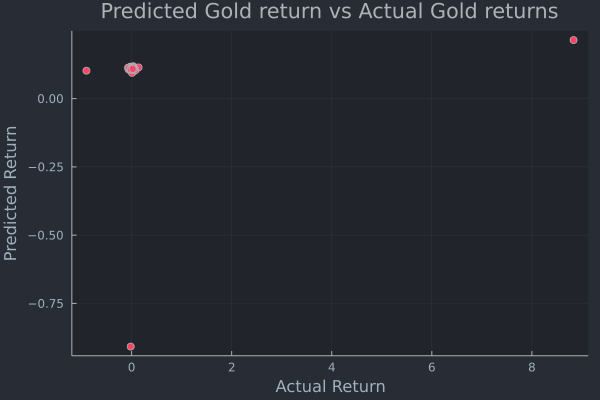

In [63]:
fm = fit(LinearModel, @formula(ReturnGold ~ FirstlagGold ), df4[1: end-3 , 1:5])
println(fm)
println("R-squared : $(r2(fm))")
prediction_train= predict(fm,df4[1: end-3 , 1:5])

p=Plots.plot(df4.ReturnGold[1: end-3] , prediction_train ,seriestype=:scatter,label=false , title = "Predicted Gold return vs Actual Gold returns")
ylabel!("Predicted Return")
xlabel!("Actual Return")

StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}}}}, Matrix{Float64}}

ReturnGold ~ 1 + FirstlagGold + ReturnCrudeOil

Coefficients:
─────────────────────────────────────────────────────────────────────────────
                    Coef.  Std. Error      t  Pr(>|t|)   Lower 95%  Upper 95%
─────────────────────────────────────────────────────────────────────────────
(Intercept)      0.112369    0.106533   1.05    0.2946  -0.0995592   0.324298
FirstlagGold    -0.114547    0.109797  -1.04    0.2999  -0.332969    0.103875
ReturnCrudeOil  -0.120545    0.804724  -0.15    0.8813  -1.7214      1.48031
─────────────────────────────────────────────────────────────────────────────
R-squared : 0.01356415754834428


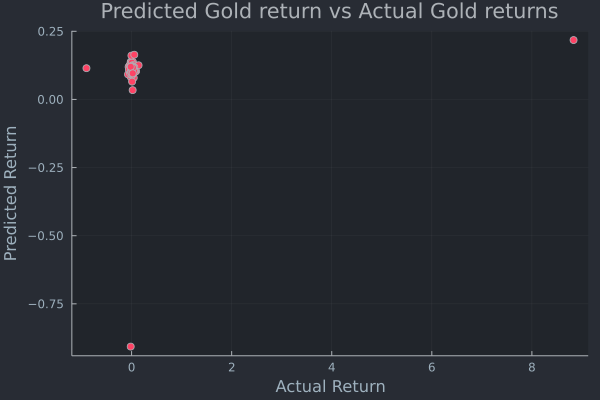

In [64]:
fm = fit(LinearModel, @formula(ReturnGold ~ FirstlagGold +ReturnCrudeOil), df4[1: end-3 , 1:5])
println(fm)
println("R-squared : $(r2(fm))")

prediction_train= predict(fm,df4[1: end-3 , 1:5])

p=Plots.plot(df4.ReturnGold[1: end-3] , prediction_train ,seriestype=:scatter,label=false , title = "Predicted Gold return vs Actual Gold returns")
ylabel!("Predicted Return")
xlabel!("Actual Return")

StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}}}}, Matrix{Float64}}

ReturnGold ~ 1 + FirstlagGold + ReturnCrudeOil + ReturnFFR

Coefficients:
─────────────────────────────────────────────────────────────────────────────
                     Coef.  Std. Error      t  Pr(>|t|)  Lower 95%  Upper 95%
─────────────────────────────────────────────────────────────────────────────
(Intercept)      0.113486     0.107854   1.05    0.2958  -0.101109   0.328081
FirstlagGold    -0.114911     0.110536  -1.04    0.3016  -0.334843   0.105022
ReturnCrudeOil  -0.0961998    0.850881  -0.11    0.9103  -1.78919    1.59679
ReturnFFR       -0.0520661    0.559698  -0.09    0.9261  -1.16569    1.06156
─────────────────────────────────────────────────────────────────────────────
R-squared : 0.0136695330402824


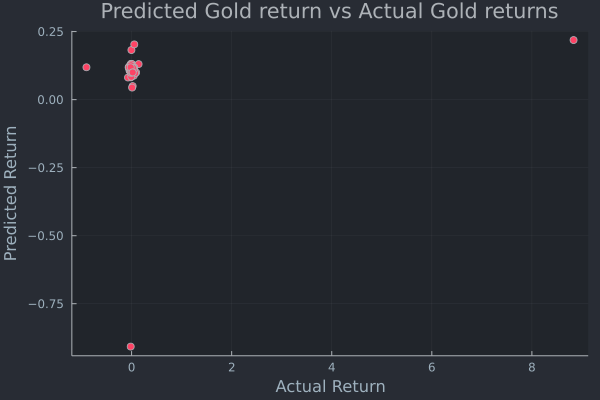

In [65]:
fm = fit(LinearModel, @formula(ReturnGold ~ FirstlagGold + ReturnCrudeOil+ReturnFFR ), df4[1: end-3 , 1:5])
println(fm)
println("R-squared : $(r2(fm))")

prediction_train= predict(fm,df4[1: end-3 , 1:5])

p=Plots.plot(df4.ReturnGold[1: end-3] , prediction_train ,seriestype=:scatter,label=false , title = "Predicted Gold return vs Actual Gold returns")
ylabel!("Predicted Return")
xlabel!("Actual Return")

By comparing the R-squared value , it seems like the third model predicts the data behavior better so we choose that one for our predictions.

In [40]:
next_month_March=coef(fm)[1]+coef(fm)[2]* df4.FirstlagGold[end-3] + coef(fm)[3] * df4.ReturnCrudeOil[end-3] + coef(fm)[4] * df4.ReturnFFR[end-3]
println(next_month_March)
print(df4.FirstlagGold[end-2]) 

0.09989365544575005
0.022798971541201807

In [70]:
next_month_April=coef(fm)[1]+coef(fm)[2]* df4.FirstlagGold[end-2] + coef(fm)[3] * df4.ReturnCrudeOil[end-2] + coef(fm)[4] * df4.ReturnFFR[end-2]
println(next_month_April)
print(df4.FirstlagGold[end-1]) 

0.012843619456343394
0.048284994509398604

In [71]:
next_month_May=coef(fm)[1]+coef(fm)[2]* df4.FirstlagGold[end-1] + coef(fm)[3] * df4.ReturnCrudeOil[end-1] + coef(fm)[4] * df4.ReturnFFR[end-1]
println(next_month_May)
print(df4.FirstlagGold[end]) 

0.08449061417922807
-0.006357128919288191